<a href="https://colab.research.google.com/github/FareedaAbdelaal/ML-55-9988/blob/main/ML_Task_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TASK 2 LAB2_1 Agglomerative Clustering



In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("CC GENERAL.csv")

df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [9]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

,0
CUST_ID,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0


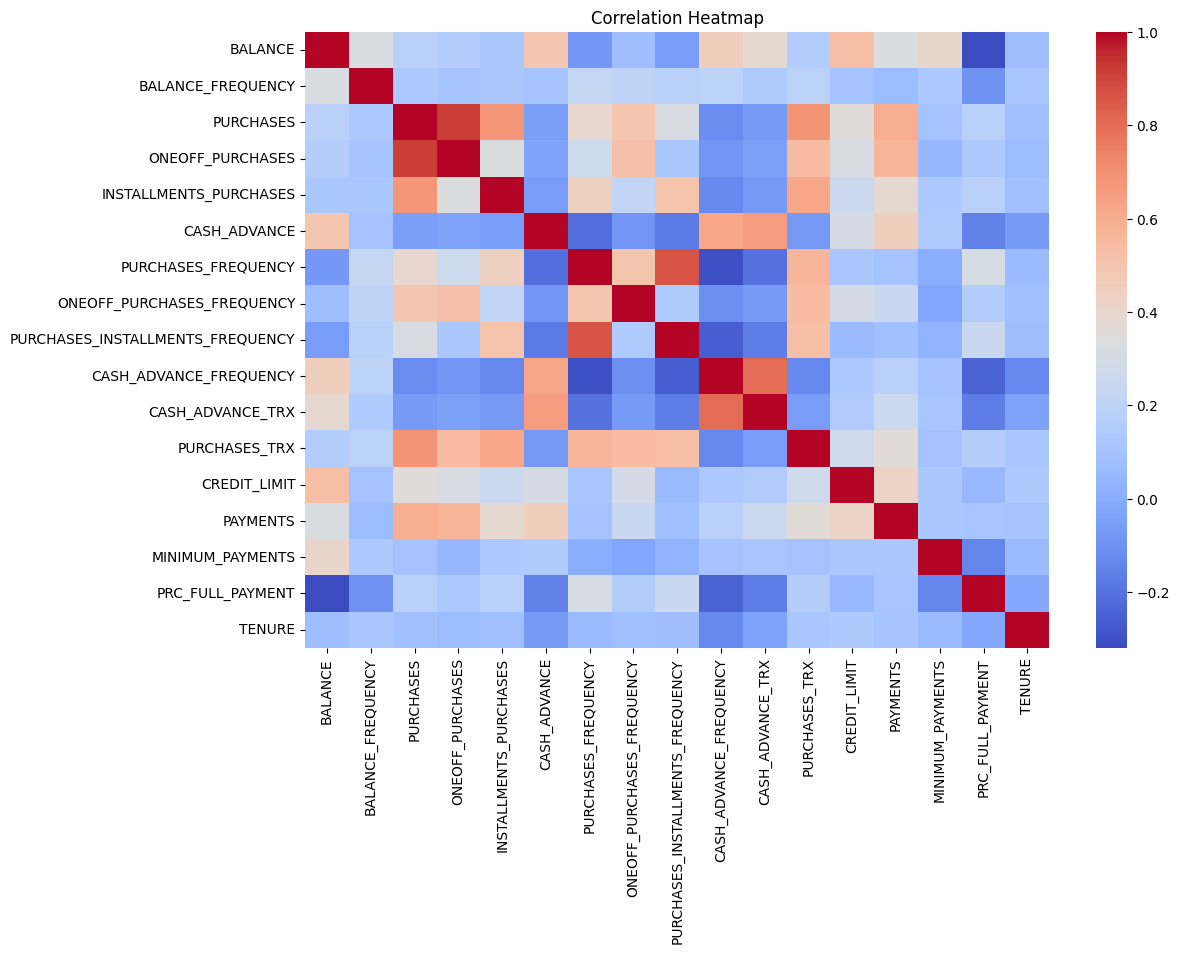

In [10]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [11]:
df = df.drop("CUST_ID", axis=1)
df.fillna(df.mean(), inplace=True)

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)
X_scaled = pd.DataFrame(X_scaled, columns=df.columns)
X_scaled.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,-0.731989,-0.249434,-0.424900,-0.356934,-0.349079,-0.466786,-0.806490,-0.678661,-0.707313,-0.675349,-0.476070,-0.511333,-0.960433,-0.528979,-3.109675e-01,-0.525551,0.36068
1,0.786961,0.134325,-0.469552,-0.356934,-0.454576,2.605605,-1.221758,-0.678661,-0.916995,0.573963,0.110074,-0.591796,0.688639,0.818642,8.931021e-02,0.234227,0.36068
2,0.447135,0.518084,-0.107668,0.108889,-0.454576,-0.466786,1.269843,2.673451,-0.916995,-0.675349,-0.476070,-0.109020,0.826062,-0.383805,-1.016632e-01,-0.525551,0.36068
3,0.049099,-1.016953,0.232058,0.546189,-0.454576,-0.368653,-1.014125,-0.399319,-0.916995,-0.258913,-0.329534,-0.551565,0.826062,-0.598688,4.878305e-17,-0.525551,0.36068
4,-0.358775,0.518084,-0.462063,-0.347294,-0.454576,-0.466786,-1.014125,-0.399319,-0.916995,-0.675349,-0.476070,-0.551565,-0.905464,-0.364368,-2.657913e-01,-0.525551,0.36068


In [13]:
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(
    n_clusters=4,
    metric='euclidean',
    linkage='ward'
)

labels = agg.fit_predict(X_scaled)

In [14]:
df["Cluster"] = labels
df.head()
df["Cluster"].value_counts()
df.groupby("Cluster").mean()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
Cluster,,,,,,,,,,,,,,,,,
0,3261.592964,0.987867,6703.434969,4494.806448,2209.860554,428.807993,0.944802,0.751209,0.766363,0.054552,1.156057,80.305955,9125.770021,6224.082423,1486.107858,0.266065,11.948665
1,1082.617273,0.784368,317.087249,190.795311,126.612072,689.243507,0.258421,0.078436,0.176230,0.113230,2.146958,4.312982,3448.347519,1031.305059,797.629549,0.112448,11.144602
2,4733.393046,0.981978,389.403808,264.281863,125.239618,4742.439786,0.204784,0.100882,0.119632,0.495628,15.153935,4.723380,7716.724537,3674.262245,1658.389287,0.031881,11.791667
3,1115.777861,0.975988,1329.751709,680.440699,649.478386,422.112009,0.868399,0.338744,0.669564,0.077173,1.842033,23.312863,4441.124655,1532.519529,632.798004,0.236684,11.958376


In [15]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [16]:
pca_df = pd.DataFrame(X_pca, columns=["PC1","PC2"])
pca_df["Cluster"] = labels

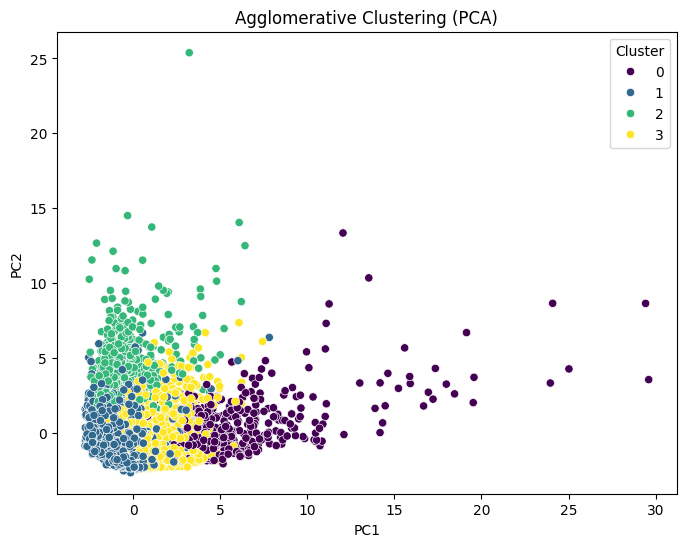

In [17]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="PC1",
    y="PC2",
    hue="Cluster",
    data=pca_df,
    palette="viridis"
)

plt.title("Agglomerative Clustering (PCA)")
plt.show()

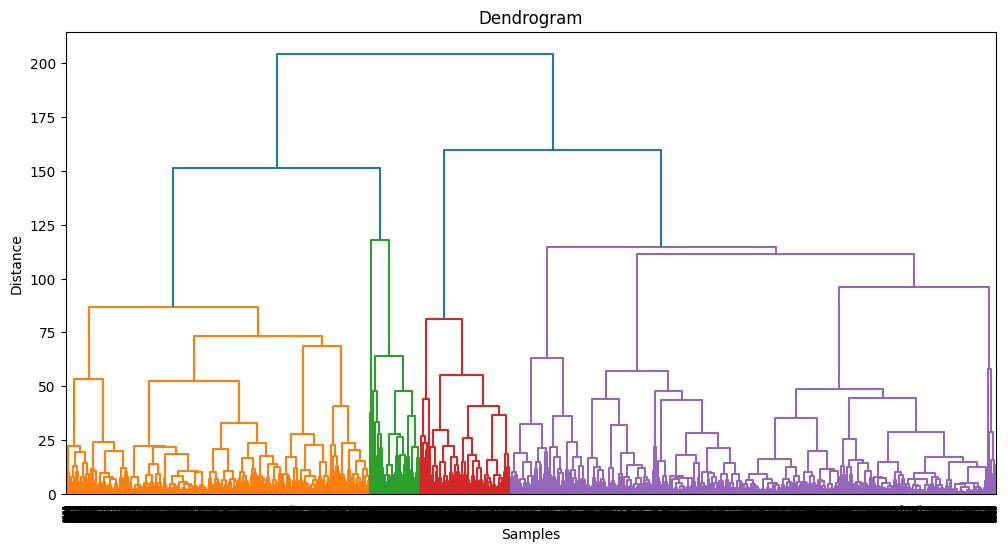

In [18]:
from scipy.cluster.hierarchy import dendrogram, linkage

Z = linkage(X_scaled, method="ward")

plt.figure(figsize=(12,6))
dendrogram(Z)
plt.title("Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

In [19]:
from sklearn.metrics import silhouette_score
sil_score = silhouette_score(X_scaled, labels)
print("Silhouette Score:", sil_score)
from sklearn.metrics import davies_bouldin_score
db_score = davies_bouldin_score(X_scaled, labels)
print("Davies-Bouldin Score:", db_score)
from sklearn.metrics import calinski_harabasz_score

ch_score = calinski_harabasz_score(X_scaled, labels)
print("Calinski-Harabasz Score:", ch_score)

Silhouette Score: 0.1547093352037027
Davies-Bouldin Score: 1.776164374959171
Calinski-Harabasz Score: 1255.6048545689366


The clustering quality was evaluated using multiple metrics including the Silhouette Score, DaviesBouldin Score, and Calinski Harabasz Score. The Silhouette Score indicates how well separated the clusters are, where values closer to 1 represent better clustering. The Davies Bouldin Score measures cluster compactness and separation, where lower values indicate better clusters. The Calinski Harabasz Score measures how well clusters are separated relative to their internal variance, where higher values indicate better clustering quality.

The PCA visualization also shows that the clusters are reasonably separated in the reduced 2 dimensional space. Therefore, the Agglomerative Clustering algorithm was able to group customers with similar credit card behavior into meaningful clusters.

TASK LAB2_2 DBSCAN Clustering


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("CC GENERAL.csv")

df.head()
df.info()
df.describe()
df.isnull().sum()
df = df.drop("CUST_ID", axis=1)
df.fillna(df.mean(), inplace=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(df)

In [22]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=1.5,
    min_samples=5
)

labels = dbscan.fit_predict(X_scaled)
df["Cluster"] = labels
df["Cluster"].value_counts()

,count
Cluster,
0,7607
-1,1319
5,7
2,5
4,5
3,4
1,3


In [23]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)
pca_df = pd.DataFrame(X_pca, columns=["PC1","PC2"])
pca_df["Cluster"] = labels

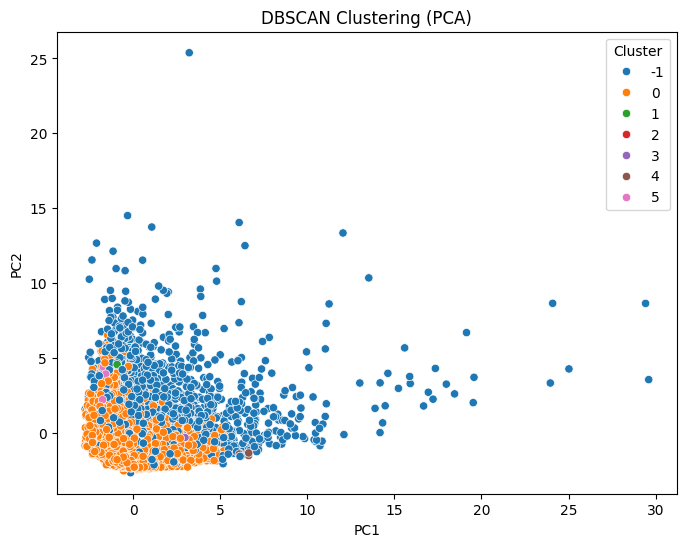

In [24]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="tab10",
    data=pca_df
)

plt.title("DBSCAN Clustering (PCA)")
plt.show()

In [25]:
from sklearn.metrics import silhouette_score
# Remove noise points for evaluation
mask = labels != -1

score = silhouette_score(X_scaled[mask], labels[mask])

print("Silhouette Score:", score)

Silhouette Score: 0.07322150865983629


DBSCAN groups data points based on density. Points located in dense regions are grouped into clusters, while points in low density areas are labeled as noise. The algorithm automatically detects the number of clusters without requiring the number of clusters as input. The silhouette score is used to evaluate cluster separation after removing noise points. The visualization using PCA shows the structure of clusters and noise points detected by DBSCAN.